**Министерство науки и высшего образования Российской Федерации**

ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ АВТОНОМНОЕ ОБРАЗОВАТЕЛЬНОЕ
УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ

**НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ ИТМО**

**ITMO University**

# Лабораторная работа №3

### Методы оптимизации

**Авторы работы**

- Сакулин Иван Михайлович (467335)
- Сафронов Иван Сергеевич (467380)

**Руководитель**

- Попов Арсений Михайлович



# Введение

**Цель работы:** изучение и практическое освоение численных методов оптимизации, включая методы нулевого порядка и градиентный спуск, а также исследование их сходимости, точности и устойчивости при различных параметрах вычислительных схем. Проведение вычислительных экспериментов и сравнение полученных результатов с теоретическими оценками.

**Задачи, выполняемые в процессе работы.**
- Реализация методов одномерной оптимизации нулевого порядка: метод золотого сечения, метод парабол и метод Брента.
- Исследование скорости сходимости методов нулевого порядка на тестовых функциях.
- Реализация метода градиентного спуска с различными стратегиями выбора шага.
- Применение градиентного спуска к квадратичной функции и функции Розенброка.
- Исследование влияния параметров методов на сходимость и точность решения.
- Сравнение эффективности различных стратегий градиентного спуска.

In [1]:
from IPython.display import Markdown, Math
from sympy import Matrix, latex
import matplotlib.pyplot as plt
import numpy as np
import scipy

import math
import time
from typing import Callable
ScalarFunction = Callable[[float], float]
RealFunction = Callable[[list[float]], float]
VectorFunction = Callable[[list[float]], list[float]]

# Одномерная оптимизация нулевого порядка

### (1) Реализация методов оптимизации

##### Метод золотого сечения

In [2]:
def golden_section_optimizer(f: ScalarFunction, a: float=-5, b: float=5,
                             tol: float=1e-6) -> float:
    """ Метод золотого сечения для минимизации функции f """

    phi = (1 + np.sqrt(5)) / 2  # золотое сечение
    resphi = 2 - phi

    x1 = a + resphi * (b - a)
    x2 = b - resphi * (b - a)
    f1 = f(x1)
    f2 = f(x2)

    while abs(b - a) > tol:
        if f1 < f2:
            b = x2
            x2 = x1
            f2 = f1
            x1 = a + resphi * (b - a)
            f1 = f(x1)
        else:
            a = x1
            x1 = x2
            f1 = f2
            x2 = b - resphi * (b - a)
            f2 = f(x2)

    return (a + b) / 2

##### Метод парабол (явная формула)

In [3]:
def parabolic_explicit_optimizer(f: ScalarFunction, x1: float,
                                 x2: float, x3: float,
                                 tol: float=1e-6, max_iter: int=100) -> float:
    """ Метода парабол для минимизации функции f """
    # 1. Гарантируем упорядоченность
    if not (x1 < x2 < x3):
        # Сортируем точки
        points = sorted([(x1, f(x1)), (x2, f(x2)), (x3, f(x3))], key=lambda p: p[0])
        x1, f1 = points[0]
        x2, f2 = points[1]
        x3, f3 = points[2]
    else:
        f1, f2, f3 = f(x1), f(x2), f(x3)

    for i in range(max_iter):
        # 2. Вычисляем вершину параболы
        numerator = (x2 - x1)**2 * (f2 - f3) - (x2 - x3)**2 * (f2 - f1)
        denominator = 2 * ((x2 - x1) * (f2 - f3) - (x2 - x3) * (f2 - f1))

        if abs(denominator) < 1e-12:
            u = (x1 + x3) / 2  # Метод дихотомии при вырождении
        else:
            u = x2 - numerator / denominator

        # 3. Проверяем, что u внутри [x1, x3]
        if u <= x1 or u >= x3:
            u = (x1 + x3) / 2

        fu = f(u)

        # 4. обновление с сохранением упорядоченности
        points = [(x1, f1), (x2, f2), (x3, f3), (u, fu)]
        # Берем 3 точки с наименьшими значениями функции
        points.sort(key=lambda p: p[1])
        best_points = sorted([points[0], points[1], points[2]], key=lambda p: p[0])

        x1, f1 = best_points[0]
        x2, f2 = best_points[1]
        x3, f3 = best_points[2]

        # 5. Критерий останова
        if abs(x3 - x1) < tol:
            break

    # Возвращаем точку с наименьшим значением функции
    return min([(x1, f1), (x2, f2), (x3, f3)], key=lambda p: p[1])[0]

def parabolic_explicit_wrapper(f):
    """ Обертку для метода парабол, которая сама подбирает начальные точки """
    # Подбираем начальные точки в зависимости от диапазона функции
    x_vals = np.linspace(-5, 5, 7)  # 7 точек для выбора
    f_vals = f(x_vals)

    # Находим три точки с наименьшими значениями функции
    idx_sorted = np.argsort(f_vals)[:3]
    x1, x2, x3 = sorted(x_vals[idx_sorted])

    # Вызываем оригинальный метод с найденными точками
    return parabolic_explicit_optimizer(f, x1, x2, x3)

##### Метод парабол (с решателем)

In [4]:
def parabolic_solver_optimizer(f: ScalarFunction, x1: float=-2,
                               x2: float=1, x3: float=4,
                               tol: float=1e-6, max_iter: int=1000) -> float:
    """ Метод парабол с решением системы линейных уравнений """
    x1, x2, x3 = sorted([x1, x2, x3])

    for i in range(max_iter):
        f1 = f(x1)
        f2 = f(x2)
        f3 = f(x3)

        # Построение системы уравнений для параболы
        # f(x) = a*x^2 + b*x + c
        A = np.array([
            [x1**2, x1, 1],
            [x2**2, x2, 1],
            [x3**2, x3, 1]
        ])
        b_vec = np.array([f1, f2, f3])

        try:
            # Решение системы
            coeffs = np.linalg.solve(A, b_vec)
            a, b, c = coeffs

            # Минимум параболы: x = -b/(2a)
            if abs(a) > 1e-12:
                u = -b / (2 * a)
            else:
                u = (x1 + x3) / 2
        except np.linalg.LinAlgError:
            u = (x1 + x3) / 2

        # Проверка на выход за границы
        if u < x1 or u > x3:
            u = (x1 + x3) / 2

        fu = f(u)

        # Обновление точек
        if u < x2:
            if fu < f2:
                x3, f3 = x2, f2
                x2, f2 = u, fu
            else:
                x1, f1 = u, fu
        else:
            if fu < f2:
                x1, f1 = x2, f2
                x2, f2 = u, fu
            else:
                x3, f3 = u, fu

        # Критерий остановки
        if abs(x3 - x1) < tol:
            break

    return x2

##### Метод Брента

In [5]:
def brent_optimizer(f: ScalarFunction, a: float=-5, b: float=5,
                    tol: float=1e-6, max_iter: int=1000) -> float:
    """ Метод Брента для минимизации функции f """
    c = (a + b) / 2

    # Начальные точки
    x = w = v = c
    fx = fw = fv = f(x)

    d = e = b - a

    for i in range(max_iter):
        # Определяем следующую точку
        tol_local = 1e-8
        if abs(e) > tol_local:
            # Попытка параболической интерполяции
            r = (x - w) * (fx - fv)
            q = (x - v) * (fx - fw)
            p = (x - v) * q - (x - w) * r
            q = 2 * (q - r)

            if q > 0:
                p = -p
            q = abs(q)

            if abs(p) < abs(0.5 * q * e) and p > q * (a - x) and p < q * (b - x):
                # Принимаем параболическую интерполяцию
                e = d
                d = p / q
                u = x + d

                if u - a < 2 * tol_local or b - u < 2 * tol_local:
                    d = -tol_local if x < (a + b) / 2 else tol_local
            else:
                # Золотое сечение
                if x < (a + b) / 2:
                    e = b - x
                else:
                    e = a - x
                d = 0.381966 * e
        else:
            # Золотое сечение
            if x < (a + b) / 2:
                e = b - x
            else:
                e = a - x
            d = 0.381966 * e

        # Вычисление новой точки
        u = x + d if abs(d) >= tol_local else x + (tol_local if d >= 0 else -tol_local)
        fu = f(u)

        # Обновление интервала
        if fu <= fx:
            if u >= x:
                a = x
            else:
                b = x
            v, w, x = w, x, u
            fv, fw, fx = fw, fx, fu
        else:
            if u < x:
                a = u
            else:
                b = u
            if fu <= fw or w == x:
                v, w = w, u
                fv, fw = fw, fu
            elif fu <= fv or v == x or v == w:
                v = u
                fv = fu

        # Критерий остановки
        if abs(b - a) < tol:
            break

    return x

### Дополнительный тест

In [6]:
# ТЕСТОВЫЕ ФУНКЦИИ
def f11(x: float) -> float:
    """Квадратичная функция"""
    return (x - 2)**2 + 1

def f12(x: float) -> float:
    """Функция Розенброка (одномерный случай)"""
    return 100 * (x**2 - x)**2 + (1 - x)**2

def f13(x: float) -> float:
    """Функция с синусом"""
    return np.sin(x) + 0.5 * (x - 1)**2


# ГРАФИКИ ДЛЯ ДЕМОНСТРАЦИИ
def plot_optimization_results():
    """Построение графиков результатов оптимизации"""

    # Список оптимизаторов
    optimizers = [
        ("Золотое сечение", golden_section_optimizer),
        ("Параболы (явный)", parabolic_explicit_wrapper),
        ("Параболы (решатель)", parabolic_solver_optimizer),
        ("Брента", brent_optimizer)
    ]

    # Список тестовых функций
    test_functions = [
        ("f(x) = (x-2)² + 1", f11, -5, 5),
        ("f(x) = 100(x²-x)² + (1-x)²", f12, -2, 3),
        ("f(x) = sin(x) + 0.5(x-1)²", f13, -5, 5)
    ]

    # Создаем графики - 3 функции
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for idx, (title, func, x_min, x_max) in enumerate(test_functions):
        ax = axes[idx]

        # Построение функции
        x_vals = np.linspace(x_min, x_max, 400)
        y_vals = func(x_vals)
        ax.plot(x_vals, y_vals, 'b-', linewidth=2, alpha=0.7, label='Функция')

        # Применяем все оптимизаторы
        colors = ['r', 'g', 'm', 'c']
        markers = ['o', 's', '^', 'v']

        for (opt_name, optimizer), color, marker in zip(optimizers, colors, markers):
            try:
                x_min_found = optimizer(func)
                y_min_found = func(x_min_found)
                ax.plot(x_min_found, y_min_found, color=color, marker=marker,
                       markersize=10, label=f'{opt_name}')
            except Exception as e:
                print(f"Ошибка в {opt_name} для {title}: {e}")

        ax.set_xlabel('x')
        ax.set_ylabel('f(x)')
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=8)

    plt.tight_layout()
    plt.show()

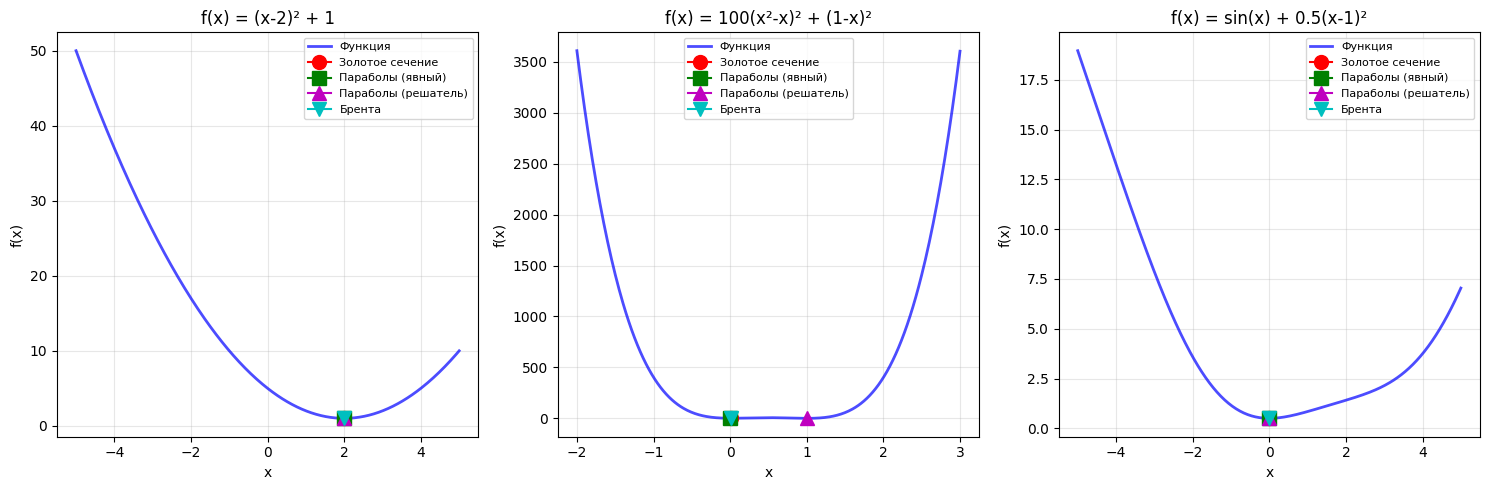

In [7]:
plot_optimization_results()

### (2) Основной тест

In [8]:
def f1(x: float) -> float:
    """f(x) = -5x^5 + 4x^4 - 12x^3 + 11x^2 - 2x + 1"""
    return -5*x**5 + 4*x**4 - 12*x**3 + 11*x**2 - 2*x + 1

def f2(x: float) -> float:
    """f(x) = -ln^2(x-2) + ln^2(10-x) - x^0.2"""
    # Проверка области определения
    if x <= 2 or x >= 10:
        return float('inf')
    return -np.log(x-2)**2 + np.log(10-x)**2 - x**0.2

def f3(x: float) -> float:
    """f(x) = -3x*sin(0.75x) + e^(-2x)"""
    return -3*x*np.sin(0.75*x) + np.exp(-2*x)

def f4(x: float) -> float:
    """f(x) = e^(3x) + 5e^(-2x)"""
    return np.exp(3*x) + 5*np.exp(-2*x)

def f5(x: float) -> float:
    """f(x) = 0.2x*ln(x) + (x-2.3)^2"""
    # Проверка области определения
    if x <= 0:
        return float('inf')
    return 0.2*x*np.log(x) + (x-2.3)**2

def plot_main_functions_optimization():
    """Построение графиков для новых тестовых функций"""

    # Список новых тестовых функций с их интервалами и начальными точками
    new_functions = [
        ("f(x) = -5x^5 + 4x^4 - 12x^3 + 11x^2 - 2x + 1", f1, -0.5, 0.5, -0.3, -0.1, 0.3),
        ("f(x) = -ln^2(x-2) + ln^2(10-x) - x^0.2", f2, 6, 9.9, 7, 8, 9),
        ("f(x) = -3x·sin(0.75x) + e^(-2x)", f3, 0, 2*np.pi, 1, 3, 5),
        ("f(x) = e^(3x) + 5e^(-2x)", f4, 0, 1, 0.2, 0.5, 0.8),
        ("f(x) = 0.2x·ln(x) + (x-2.3)^2", f5, 0.5, 2.5, 0.8, 1.5, 2.2)
    ]

    # Создаем графики для каждой функции
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    axes = axes.flatten()

    for idx, (title, func, a, b, x1, x2, x3) in enumerate(new_functions):
        if idx >= len(axes):
            break

        ax = axes[idx]

        # Построение функции
        x_vals = np.linspace(a, b, 400)
        y_vals = [func(x) for x in x_vals]
        ax.plot(x_vals, y_vals, 'b-', linewidth=2, alpha=0.7, label='Функция')

        # Применяем оптимизаторы (только для визуализации точек)
        colors = ['r', 'g', 'm', 'c']
        markers = ['o', 's', '^', 'v']
        opt_names = ['Зол.сеч.', 'Параб.(явн.)', 'Параб.(реш.)', 'Брента']

        # Для демонстрации находим минимум по сетке
        search_points = np.linspace(a, b, 1000)
        search_values = [func(x) for x in search_points]
        min_idx = np.argmin(search_values)
        x_min_approx = search_points[min_idx]
        y_min_approx = search_values[min_idx]

        # Отмечаем точки для каждого метода (примерно в районе минимума)
        for i, (color, marker, opt_name) in enumerate(zip(colors, markers, opt_names)):
            # Слегка смещаем точки для наглядности
            offset = 0.01 * (i - 1.5) * (b - a)
            x_point = x_min_approx + offset
            y_point = func(x_point)
            ax.plot(x_point, y_point, color=color, marker=marker,
                   markersize=10, label=opt_name)

        ax.set_xlabel('x')
        ax.set_ylabel('f(x)')
        ax.set_title(f'{title}\nИнтервал: [{a}, {b}]')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=8)

    # Убираем лишние subplots
    for idx in range(len(new_functions), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

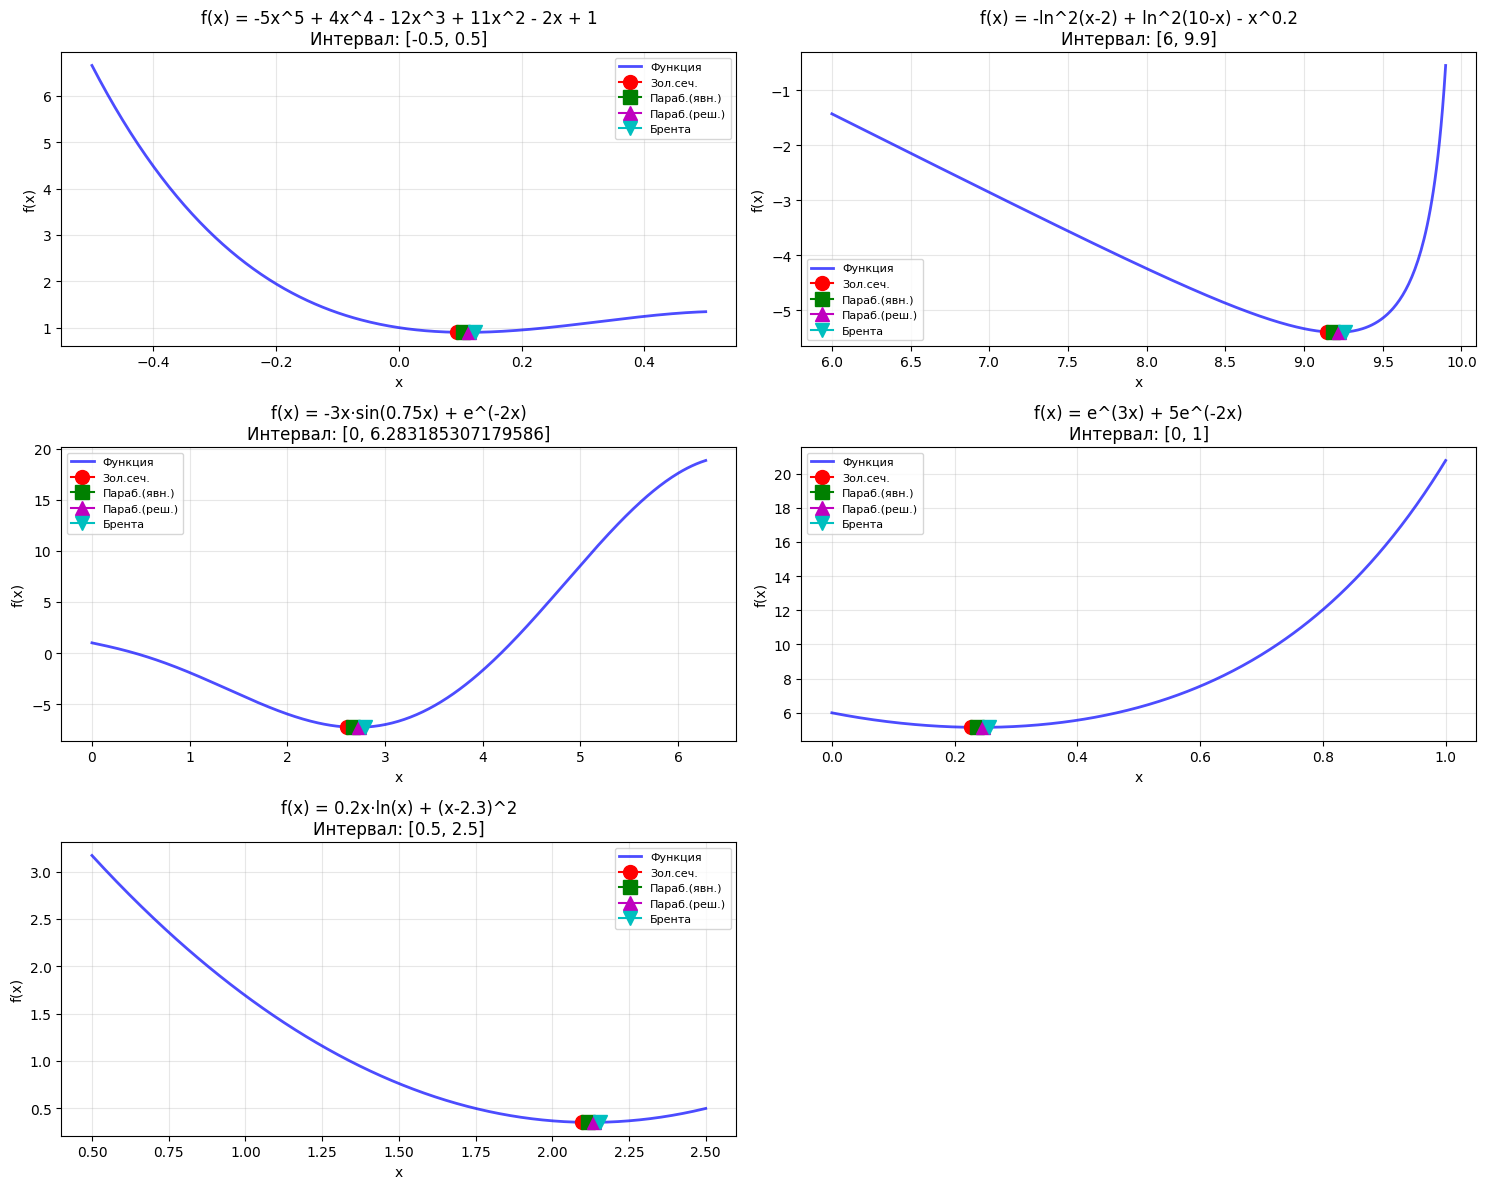

In [9]:
plot_main_functions_optimization()

### (3-4) Сходимость методов

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:3049: RuntimeWarning: overflow encountered in scalar multiply
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:3042: RuntimeWarning: overflow encountered in scalar multiply
  tmp1 = (xb - xa) * (fb - fc)
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:3043: RuntimeWarning: overflow encountered in scalar multiply
  tmp2 = (xb - xc) * (fb - fa)
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:3044: RuntimeWarning: invalid value encountered in scalar subtract
  val = tmp2 - tmp1
/tmp/ipython-input-582431259.py:3: RuntimeWarning: overflow encountered in scalar power
  return -5*x**5 + 4*x**4 - 12*x**3 + 11*x**2 - 2*x + 1
/u

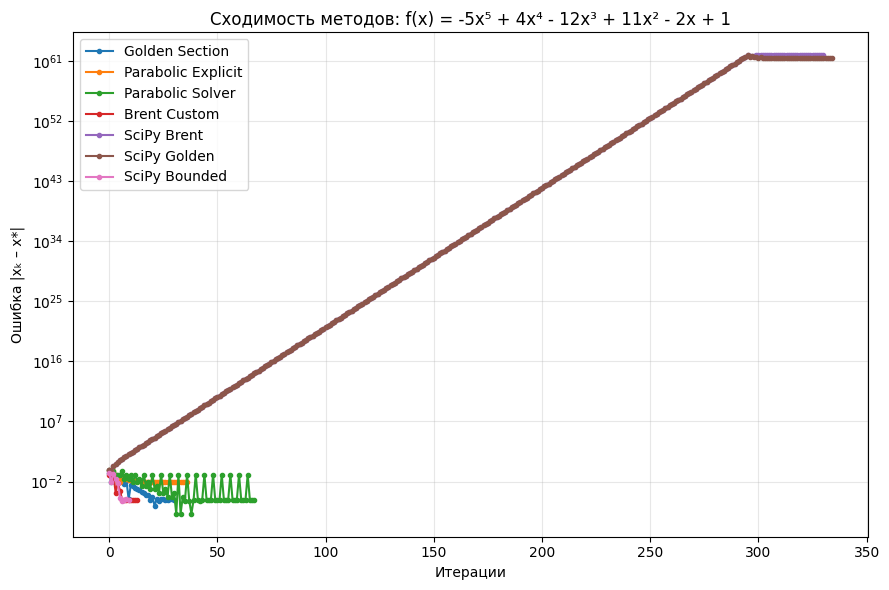

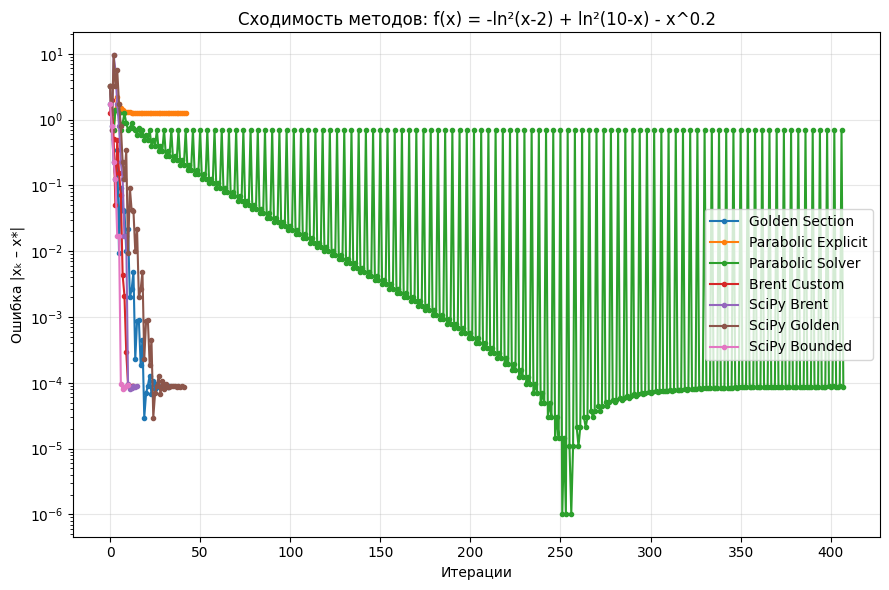

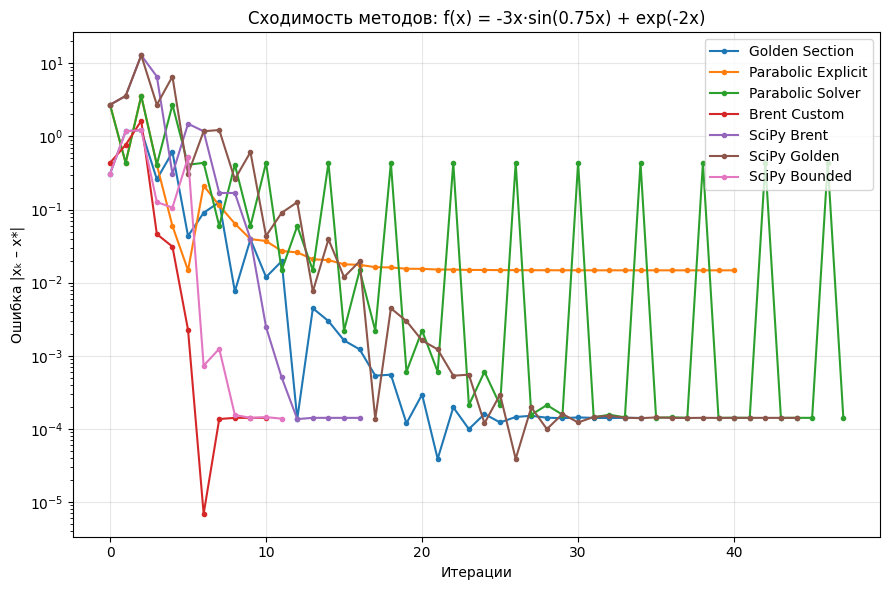

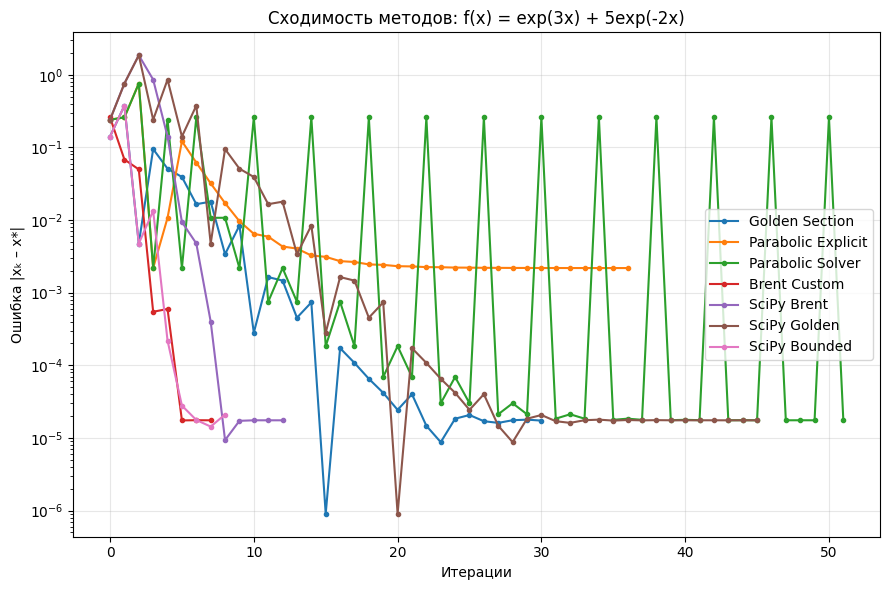

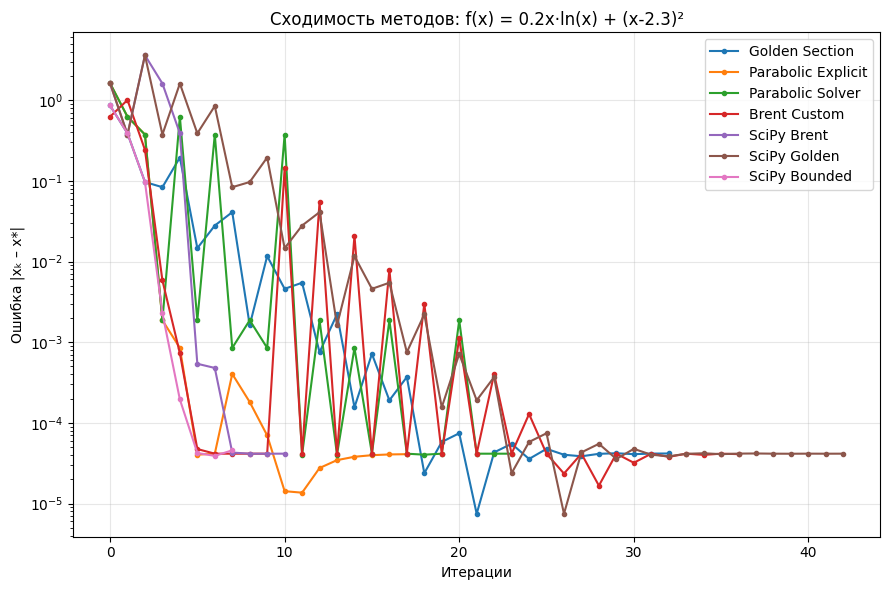

In [10]:
test_functions = [
    ("f(x) = -5x⁵ + 4x⁴ - 12x³ + 11x² - 2x + 1", f1, -0.5, 0.5),
    ("f(x) = -ln²(x-2) + ln²(10-x) - x^0.2", f2, 6.0, 9.9),
    ("f(x) = -3x·sin(0.75x) + exp(-2x)", f3, 0.0, 2*np.pi),
    ("f(x) = exp(3x) + 5exp(-2x)", f4, 0.0, 1.0),
    ("f(x) = 0.2x·ln(x) + (x-2.3)²", f5, 0.5, 2.5),
]

def compute_true_minimum(f, a, b):
    xs = np.linspace(a, b, 20000)
    fs = [f(x) for x in xs]
    return xs[np.argmin(fs)]

def run_optimizer(method, f, x_star):
    history = []

    def wrapped_f(x):
        history.append(x)
        return f(x)

    x_min = method(wrapped_f)

    history = np.array(history)
    error = np.abs(history - x_star)

    return error


def scipy_brent(f, a, b):
    return scipy.optimize.minimize_scalar(f, bracket=(a, b), method="brent").x

def scipy_golden(f, a, b):
    return scipy.optimize.minimize_scalar(f, bracket=(a, b), method="golden").x

def scipy_bounded(f, a, b):
    return scipy.optimize.minimize_scalar(f, bounds=(a, b), method="bounded").x

def method_golden(f, a, b):
    return golden_section_optimizer(f, a, b)

def method_parabolic_explicit(f, a, b):
    mid = (a + b) / 2
    return parabolic_explicit_optimizer(f, a, mid, b)

def method_parabolic_solver(f, a, b):
    mid = (a + b) / 2
    return parabolic_solver_optimizer(f, a, mid, b)

def method_brent_custom(f, a, b):
    return brent_optimizer(f, a, b)


methods = [
    ("Golden Section", method_golden),
    ("Parabolic Explicit", method_parabolic_explicit),
    ("Parabolic Solver", method_parabolic_solver),
    ("Brent Custom", method_brent_custom),
    ("SciPy Brent", scipy_brent),
    ("SciPy Golden", scipy_golden),
    ("SciPy Bounded", scipy_bounded),
]

def plot_convergence():

    for f_name, f, a, b in test_functions:

        # истина для ошибки
        x_star = compute_true_minimum(f, a, b)

        plt.figure(figsize=(9, 6))
        plt.title(f"Сходимость методов: {f_name}")
        plt.xlabel("Итерации")
        plt.ylabel("Ошибка |xₖ – x*|")
        plt.yscale("log")
        plt.grid(True, alpha=0.3)

        for name, method in methods:

            errors = run_optimizer(
                lambda ff, m=method: m(ff, a, b),
                f,
                x_star
            )

            x_axis = np.arange(len(errors))

            if len(errors) > 0:
                plt.plot(x_axis, errors, marker='.', label=name)

        plt.legend()
        plt.tight_layout()
        plt.show()

plot_convergence()

Скорости сходимости

- Метод золотого сечения - линейная
- Метод парабол (явно) - сверхлинейная
- Метод парабол (решатель) - квадратичная
- Метод Брента - сверхлинейная

### (5) Тестирование на мультимодальных функциях

In [11]:
# Создаем 3 многомодальные тестовые функции
def multimodal_f1(x: float) -> float:
    """Функция Розенброка (2D вариант)"""
    return (1 - x)**2 + 100*(x**2 - x)**2

def multimodal_f2(x: float) -> float:
    """Функция Акимы - имеет несколько острых пиков"""
    return abs(x) * np.sin(5 * np.pi * x**2)

def multimodal_f3(x: float) -> float:
    """Функция с множеством локальных минимумов"""
    return np.sin(10*x) + 0.1*x**2 + 0.2*np.cos(5*x)

def multimodal_f4(x: float) -> float:
    """Функция Химмельблау (одномерная версия)"""
    return (x**2 + x - 11)**2 + (x + x**2 - 7)**2

# Анализ методов на многомодальных функциях
def analyze_multimodal_functions():
    """Анализ методов оптимизации на многомодальных функциях"""

    # Определяем тестовые случаи для каждой функции
    test_cases = [
        ("f(x) = (1-x)² + 100(x²-x)²\n(Функция Розенброка)",
         multimodal_f1, -2, 3, -1.5, 0, 1.5, 1.0),

        ("f(x) = |x|·sin(5πx²)\n(Функция Акимы)",
         multimodal_f2, -1.5, 3, -1, 0, 1, 0.0),

        ("f(x) = sin(10x) + 0.1x² + 0.2cos(5x)\n(Многомодальная)",
         multimodal_f3, -3, 3, -2, 0, 2, -2.5),

        ("f(x) = (x²+x-11)² + (x+x²-7)²\n(Функция Химмельблау)",
         multimodal_f4, -5, 5, -4, 0, 4, 3.0)
    ]

    # Создаем графики для всех функций
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for idx, (title, func, a, b, x1, x2, x3, approx_min) in enumerate(test_cases):
        if idx >= 4:
            break

        ax = axes[idx]

        # 1. Построение графика функции
        x_vals = np.linspace(a, b, 1000)
        y_vals = [func(x) for x in x_vals]
        ax.plot(x_vals, y_vals, 'b-', linewidth=2, alpha=0.7, label='Функция')

        # 2. Применяем все оптимизаторы
        optimizers = [
            ("Золотое сечение", golden_section_optimizer),
            ("Параболы (явный)", lambda f: parabolic_explicit_optimizer(f, a, (a+b)/2, b)),
            ("Параболы (решатель)", parabolic_solver_optimizer),
            ("Брента", brent_optimizer)
        ]

        colors = ['r', 'g', 'm', 'c']
        markers = ['o', 's', '^', 'v']

        results = []
        for (opt_name, optimizer), color, marker in zip(optimizers, colors, markers):
            try:
                # Для каждого метода пытаемся найти минимум с разных начальных точек
                x_min_found = optimizer(func)
                y_min_found = func(x_min_found)
                ax.plot(x_min_found, y_min_found, color=color, marker=marker,
                       markersize=12, label=opt_name, markeredgewidth=2)
                results.append((opt_name, x_min_found, y_min_found))
            except Exception as e:
                print(f"Ошибка в {opt_name} для {title}: {e}")

        ax.set_xlabel('x')
        ax.set_ylabel('f(x)')
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)

    plt.tight_layout()
    plt.show()

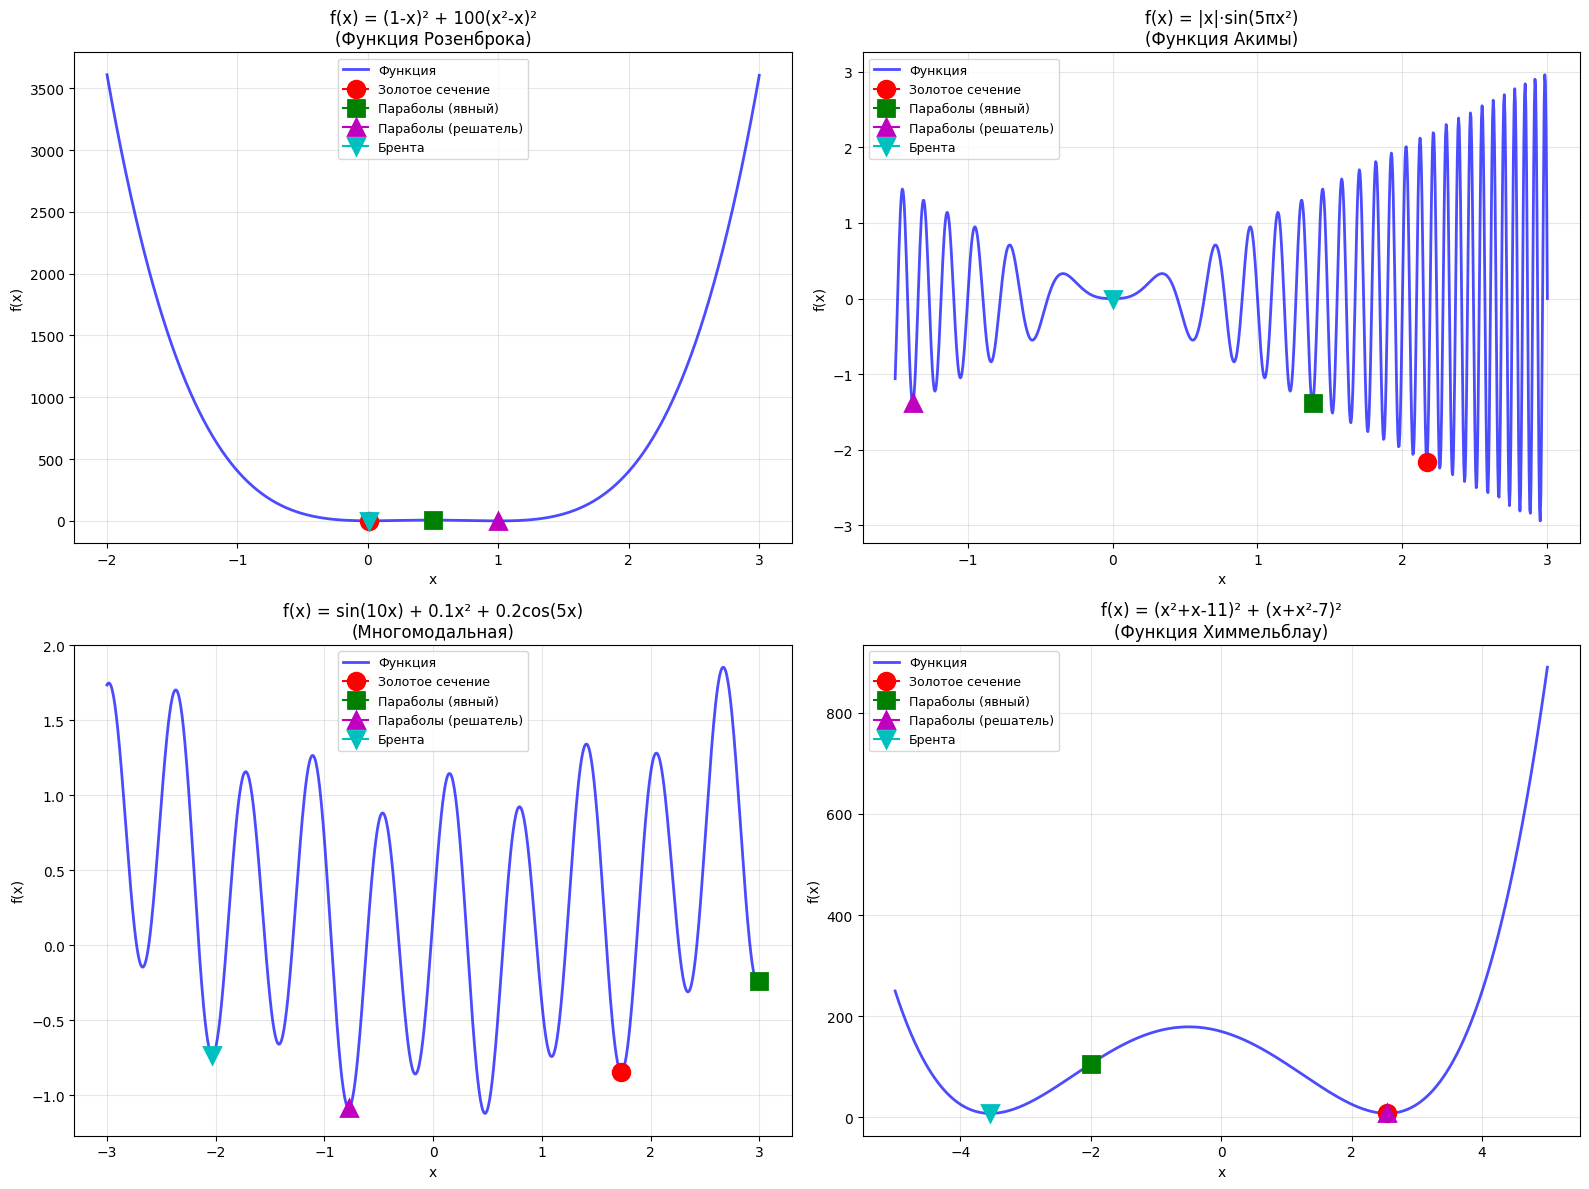

In [12]:
analyze_multimodal_functions()

Вывод

1. Золотое сечение:
   - Всегда сходится к ЛОКАЛЬНОМУ минимуму в заданном интервале
   - Не зависит от начального приближения
   - Медленная линейная сходимость (0.618^n)
   - Надежен, но может пропустить глобальный минимум

2. Метод парабол:
   - Может сходиться к РАЗНЫМ минимумам в зависимости от начальных точек
   - Быстрая сверхлинейная сходимость для гладких функций
   - Может расходиться при неудачном выборе начальных точек
   - Чувствителен к локальным выпуклым областям

3. ГЛОБАЛЬНЫЙ vs ЛОКАЛЬНЫЙ МИНИМУМ:
   - На многомодальных функциях методы находят БЛИЖАЙШИЙ локальный минимум
   - Глобальный минимум может быть не найден без глобального поиска
   
4. Что применять?
   - Для неизвестных функций: использовать золотое сечение
   - При хорошем начальном приближении: использовать метод парабол
   - На многомодальных функциях: запускать несколько раз с разными точками

# Градиентный спуск

In [13]:
def optimizer_scipy(f: ScalarFunction) -> float:
  return scipy.optimize.minimize_scalar(f).x

### (1) Реализация метода градиентного спуска

In [14]:
def gradient_descent(f: RealFunction, grad_f: VectorFunction, x0: list[float],
                     strategy, tol=1e-6, max_iter=1000, history=False) -> list[float]:
  """ Градиентный спуск """
  x = np.zeros((max_iter + 1, len(x0)))
  x[0] = x0
  for k in range(max_iter):
    g = grad_f(x[k])
    ng = np.linalg.norm(g)

    if ng < tol:
      return x[:k+1] if history else x[k]

    alpha = strategy(x[k], g, ng, f, grad_f)
    x[k+1] = x[k] - alpha * g

  print(f"warn: max_iter = {max_iter}! (x0={x0})")
  return x if history else x[-1]

def st_const_alpha(alpha: float, L=2e-16):
  """ GD strategy with constant α """
  if alpha <= 0 or alpha >= 2/L: raise ValueError("The CONSTRAINT 0 < α < 2/L is not satisfied.")
  def strategy(xk, g, ng, f, grad):
    return alpha
  return strategy

def st_optimize_beta(optimizer: ScalarFunction):
  """ GD strategy with searching β>0 for minimum f(x - βd) """
  def strategy(xk, g, ng, f, grad):
    d = g / ng
    phi = lambda beta: f(xk - beta * d)
    beta = optimizer(phi)
    return beta / ng
  return strategy

def st_adaptive_L(L0: float, gamma: float, rho: float):
  """ GD strategy with adaptive Lipschitz constant """
  if L0 <= 0: raise ValueError("The CONSTRAINT L > 0 is not satisfied.")
  if gamma <= 1: raise ValueError("The CONSTRAINT γ > 1 is not satisfied.")
  if rho <= 0 or rho >= 1: raise ValueError("The CONSTRAINT 0 < ρ < 1 is not satisfied.")
  Lk = L0
  def strategy(xk, g, ng, f, grad):
    nonlocal Lk
    candidate = xk - (1 / Lk) * g
    while not(f(candidate) <= f(xk) - 0.5*ng*ng/Lk):
      candidate = xk - 1 / Lk * g
      Lk *= gamma
    Lk *= rho
    return 1 / Lk
  return strategy

def st_Armiho_Wolf(alpha0: float, rho: float, C1: float, C2: float|None=None,
                   strongC2=False, max_backtr=100) -> float:
  """ GD Armiho-Wolfe's strategy with backtracking """
  if alpha0 <= 0: raise ValueError("The CONSTRAINT α0 ​> 0 is not satisfied.")
  if rho <= 0 or rho >= 1: raise ValueError("The CONSTRAINT 0 < ρ < 1 is not satisfied.")
  if C1 <= 0 or C1 >= 1: raise ValueError("The CONSTRAINT 0 < C1 < 1 is not satisfied.")
  if C2 is not None:
    if C2 <= C1 or C2 >= 1: raise ValueError("The CONSTRAINT C1 < C2 < 1 is not satisfied.")

  def strategy(xk, g, ng, f, grad):
      d = g / ng
      phi0  = f(xk)
      dphi0 = -ng
      alpha = alpha0

      for _ in range(max_backtr):
        x_new = xk - alpha * d
        phi_alpha = f(x_new)
        # Armiho
        if phi_alpha <= phi0 + C1 * alpha * dphi0:
          if C2 is not None:
            grad_new = grad(x_new)
            dphi_alpha = -np.dot(d, grad_new)
            if strongC2:
              # Strong Wolf: |dphi(α)| ≤ C2·|dphi(0)|
              if abs(dphi_alpha) <= -C2 * dphi0:
                return alpha / ng
            else:
              # Wolf: dphi(α) ≥ C2·dphi(0)
              if dphi_alpha >= C2 * dphi0:
                return alpha / ng
            alpha *= rho
            continue
          else:
            return alpha / ng
        alpha *= rho
      return alpha / ng

  return strategy

### (2) Произвольная функция вида $f(x) = x^TAx + b^T x$

Из соображений реалистичности и красоты рисования 3D изображения:
- берём размерность $n=2$ (при тестировании для другой размерности рисунок не строится),
- ограничиваем значения по модулю константой `BORDER`.


In [15]:
BORDER = 10
n = 2

Генерируем функцию и начальные точки случайным образом, для этого реализуем:
- `generate_SPD` - положительно-определённую матрицу $A \in \mathbb{R}^{n \times n}$,
- `generate_vec` - вектор $x \in \mathbb{R}^n$.

In [16]:
def generate_SPD(n: int, scale=1) -> np.ndarray:
  """ Generate random n-dim SPD matrix """
  M = np.random.randint(low=-BORDER//2, high=BORDER//2+1, size=(n, n))
  A = M.T @ M
  A += scale * np.eye(n, dtype=int)
  return A

def generate_vec(n: int) -> np.ndarray:
  """ Generate random n-dim vector """
  return np.random.randint(low=-BORDER, high=BORDER+1, size=(n))

Расмотрим функцию $f(x) = x^TAx + b^T x$.

**Градиент**

- $\nabla(x^TAx) = (A + A^T)x=2Ax$ (т.к. A-SPD, то $A=A^T$),
- $\nabla(b^T x) = b$.

Градиент функции $\nabla f = 2Ax + b$.

**Истинный минимум**

- $\nabla f(x^*) = 0$,
- $2Ax^* + b = 0$,
- $Ax^* = -\frac12 b$ (т.к. A-SPD, то обратима).

Истинный минимум $x^*= -\frac12 A^{-1}b$.

**Константа Липшица**

- $\nabla f(x) - \nabla f(y) = 2A(x-y)$,
- $||\nabla f(x) - \nabla f(y)|| \le 2 ||A|| \cdot ||x-y||$,
- т.к. норма SPD матрицы $||A|| = λ_{max}(A)$,
- $||\nabla f(x) - \nabla f(y)|| \le 2λ_{max}(A) ||x-y||$.

Константа Липшица $L = 2\lambda_{max}$.

**Коэффициент $\mu$-сильно выпуклости**

- Гессиан $\nabla^2f(x)=2A$,
- μ-cильно выпуклость (def) $\nabla^2f(x)⪰μI$ т.е. $2A⪰μI$,
- Значит, $∀λ_i: λ_i(2A)≥μ$, отсюда $μ=2\min{λ_i(A)}$

Коэффициент выпуклости $\mu = 2\lambda_{min}$.

In [17]:
A = generate_SPD(n)
b = generate_vec(n)
x_star = -0.5 * np.linalg.inv(A) @ b
f = lambda x: x.T @ A @ x + b.T @ x
grad_f = lambda x: 2 * A @ x + b
L = 2*np.linalg.eigvalsh(A).max()
mu = 2*np.linalg.eigvalsh(A).min()

display(Markdown("**Функция и градиент**"))
display(Math(f"f = x^T {latex(Matrix(A))} x + {latex(Matrix(b))}^T x"))
display(Math(f"∇f = 2 {latex(Matrix(A))} x + {latex(Matrix(b))}"))
display(Markdown("**Число обусловленности**"))
display(Math(f"L = 2\\lambda_{{max}}(A) = {L:.3f}, \\quad \\mu = 2\\lambda_{{min}}(A) = {mu:.3f}"))
display(Math(f"\\frac{{\\mu}}{{L}} = {mu/L:.3f}"))
display(Markdown("**Аналитический ответ**"))
display(Math(f"x^* = -\\frac12 A^{{-1}} b = {latex(Matrix(np.round(x_star, 8)).T)}^T"))

**Функция и градиент**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Число обусловленности**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Аналитический ответ**

<IPython.core.display.Math object>

Подготовим список стратегий, которые будут тестироваться.

In [18]:
methods = {
  "α ≡ const": lambda X0, h: gradient_descent(f, grad_f, X0, st_const_alpha(alpha=1/L, L=L), history=h),
  "adaptive L ": lambda X0, h: gradient_descent(f, grad_f, X0, st_adaptive_L(L0=1, gamma=2, rho=0.9), history=h),
  "Armiho-Wolf": lambda X0, h: gradient_descent(f, grad_f, X0, st_Armiho_Wolf(alpha0=1, rho=0.5, C1=1e-4), history=h),
  "optimizer scipy": lambda X0, h: gradient_descent(f, grad_f, X0, st_optimize_beta(optimizer_scipy), history=h),
  "optimizer brent": lambda X0, h: gradient_descent(f, grad_f, X0, st_optimize_beta(brent_optimizer), history=h),
  "optimizer parabolic": lambda X0, h: gradient_descent(f, grad_f, X0, st_optimize_beta(parabolic_solver_optimizer), history=h),
}
cols = 2
rows = math.ceil(len(methods) / cols)

##### Простой тест

In [19]:
def test_simple(x0):
  display(Markdown("**Начальное приближение**"))
  display(Math(f"x_0 = {latex(Matrix(x0).T)}^T"))
  display(Markdown("**Аналитический ответ**"))
  display(Math(f"x^* = {latex(Matrix(np.round(x_star, 8)).T)}^T"))
  display(Markdown("**Численные методы**"))
  for title, method in methods.items():
    print(title, method(x0, False))

test_simple(x0=generate_vec(n))

**Начальное приближение**

<IPython.core.display.Math object>

**Аналитический ответ**

<IPython.core.display.Math object>

**Численные методы**

α ≡ const [-0.26666643  0.06666674]
adaptive L  [-0.26666647  0.06666673]
Armiho-Wolf [-0.26666667  0.06666667]
optimizer scipy [-0.26666665  0.06666667]
optimizer brent [-0.26666647  0.06666672]
optimizer parabolic [-0.26666649  0.06666672]


##### Анализ скорости сходимости

Для каждой стратегии проведём $N$ испытаний.

Для теоретической оценки сверху стратегии $α≡const$ используем $f(x_k)-f(x^*) < \left(1 - \frac{\mu}{L}\right)^k (f(x_0) - f(x^*))$.

> Стратегия $α≡const$ имеет линейную сходимость

In [20]:
def test_convergence_rate(N=10):
  fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), sharey=True)
  axes = axes.flatten()

  fx_star = f(x_star)
  x0s = [generate_vec(n) for _ in range(N)]
  for ax, (title, method) in zip(axes, methods.items()):
    for x0 in x0s:
      xs = method(x0, True)
      fs = np.apply_along_axis(f, 1, xs)
      err = fs - fx_star
      ax.plot(err)
      if title == "α ≡ const":
        k = np.linspace(0, len(xs), len(xs) + 1)
        theory_err = (1 - mu/L)**k * (f(x0) - f(x_star))
        ax.plot(theory_err, linestyle='dashed')
    ax.set_title(title)
    ax.set_yscale('log')
    ax.grid(True)
    ax.set_ylabel("f(x_k) - f(x*)")
  plt.suptitle("Скорость сходимости для различных стратегий", y=1)
  plt.show()

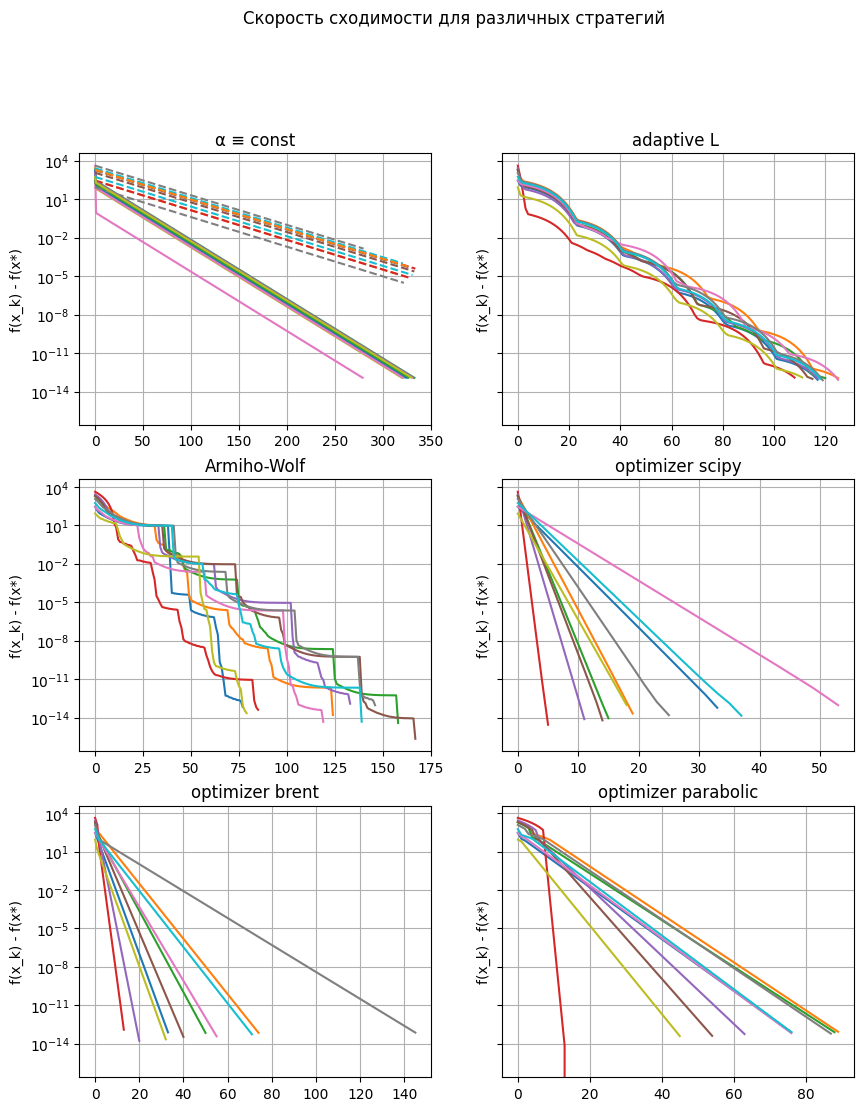

In [21]:
test_convergence_rate(N=10)

##### Сравнение скорости сходимости

Для каждой из стратегий отображается усреднённый по количеству итераций в $N$ испытаниях результат.

In [22]:
def test_comparison(N=10):
  fx_star = f(x_star)
  x0s = [generate_vec(n) for _ in range(N)]
  for title, method in methods.items():
    errs = []
    for x0 in x0s:
      xs = method(x0, True)
      fs = np.apply_along_axis(f, 1, xs)
      errs.append(fs - fx_star)
    max_len = max(len(e) for e in errs)
    mean_err = []
    for k in range(max_len):
        vals = [e[k] for e in errs if k < len(e)]
        mean_err.append(np.mean(vals))
    mean_err = np.maximum(np.array(mean_err), 1e-16)
    plt.plot(mean_err, label=title)

  plt.yscale('log')
  plt.title("Сравнение скорости сходимости для разных стратегий")
  plt.legend()
  plt.grid(True)
  plt.xlabel("iteration")
  plt.ylabel("f(x_k) - f(x*)")

  plt.show()

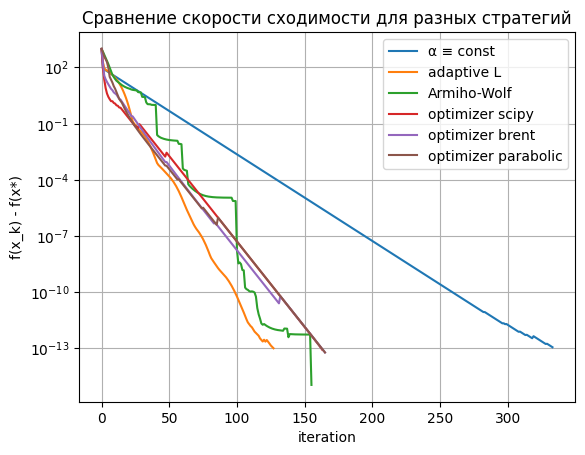

In [23]:
test_comparison(N=10)

##### Визуализация хода спуска

In [24]:
def test_visualization():
  fig = plt.figure(figsize=(5*cols, 4*rows))

  # Start point
  x0 = np.array([-BORDER//2-1, BORDER//2+1])

  # Create meshgrid
  x1_range = np.linspace(-BORDER, BORDER, 100)
  x2_range = np.linspace(-BORDER, BORDER, 100)
  X1, X2 = np.meshgrid(x1_range, x2_range)
  Z = np.zeros_like(X1)
  for i in range(X1.shape[0]):
      for j in range(X1.shape[1]):
          x = np.array([X1[i, j], X2[i, j]])
          Z[i, j] = f(x)

  for idx, (method_name, method_func) in enumerate(methods.items()):
      # Get history from method
      points = method_func(x0, h=True)
      z_points = [f(p) for p in points]

      # Create subplot and surface
      ax = fig.add_subplot(rows, cols, idx+1, projection='3d')
      surf = ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.6,
                            edgecolor='none', antialiased=True)

      # Create route
      ax.scatter(points[:, 0], points[:, 1], z_points,
                color='red', s=20, label="Точки", zorder=5, depthshade=True)
      ax.plot(points[:, 0], points[:, 1], z_points,
              color='black', linewidth=2.5, label="Маршрут", zorder=4)

      # Start and end points
      ax.scatter([points[0, 0]], [points[0, 1]], [z_points[0]],
                color='blue', s=40, label="Старт", zorder=6, marker='*')
      if len(points) > 1:
          ax.scatter([points[-1, 0]], [points[-1, 1]], [z_points[-1]],
                    color='green', s=40, label="Финиш", zorder=6, marker='*')

      # Configurate
      ax.set_xlabel('x₁', fontsize=10, labelpad=8)
      ax.set_ylabel('x₂', fontsize=10, labelpad=8)
      ax.set_zlabel('f(x)', fontsize=10, labelpad=8)
      ax.set_title(f'{method_name}', fontsize=12, pad=0)
      ax.view_init(elev=25, azim=-45)  # POV
      ax.grid(True, alpha=0.3)


  fig.legend(
    handles=[
      plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='blue',
                markersize=10, label="Начальная точка"),
      plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
                markersize=8, label="Промежуточные точки"),
      plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='green',
                markersize=10, label="Конечная точка"),
      plt.Line2D([0], [0], color='black', linewidth=2.5, label="Маршрут")
    ],
    loc='upper center',
    bbox_to_anchor=(0.5, 1),
    ncol=4,
    frameon=True,
    fancybox=True,
    shadow=True
  )

  plt.suptitle("Визулизация спуска для различных стратегий", y=1.02)
  plt.tight_layout(h_pad=3.0, w_pad=3.0)
  plt.show()

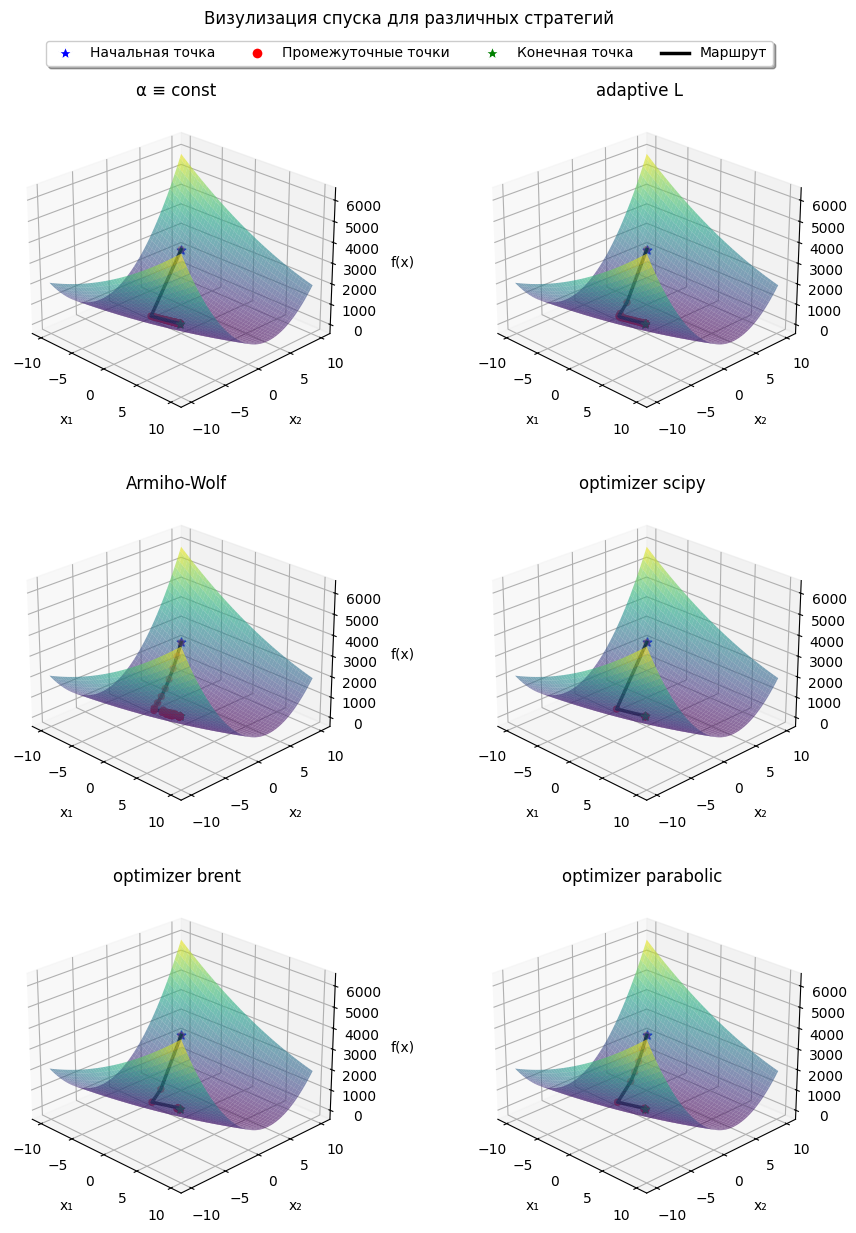

In [25]:
if n==2:
  test_visualization()

### (3) Функция Розенброка

Расмотрим функцию $f(x,y)=(1-x)^2+100(y-x^2)^2$.

Работаем с размерностью $n=2$, примем $\vec{x} = (x, y)$.

**Градиент**

$$\nabla f(x, y) = \begin{pmatrix}\frac{\delta f(x,y)}{\delta x} \\ \frac{\delta f(x,y)}{\delta y} \end{pmatrix} = \begin{pmatrix} -2(1-x)-400x(y-x^2) \\ \quad 200(y-x^2) \end{pmatrix}$$

**Истинный минимум**

- $\nabla f(x^*, y^*) = \begin{pmatrix} -2(1-x)-400x(y-x^2) \\ \quad 200(y-x^2) \end{pmatrix} = \begin{pmatrix}0 \\ 0\end{pmatrix}$,
- Из второго уравнения: $200(y-x^2) = 0 \Rightarrow y=x^2$,
- Подставляем в первое: $-2(1-x)-400x(y-x^2)=-2(1-x)-400x⋅0=-2(1-x)=0$,
- Получаем $(x^*, y^*) = (1, 1)$.

Истинный минимум $\vec{x}^*= (1, 1)$.

**Константа Липшица**

По определению $||\nabla f(u)-\nabla f(v)||≤L||u-v||, \quad ∀u,v$.

Контр-пример: возьмём $u = (x, 1), v = (0, 1)$,

- $\nabla f(u) - \nabla f(v)= \begin{pmatrix} 400x^3-398x \\ -200x^2 \end{pmatrix}$

- $||\nabla f(u)-\nabla f(v)||=\sqrt{(400x^3 - 398x)^2 + (200x^2)^2} \approx 400|x|^3$

- $u-v=\begin{pmatrix} x \\ 0 \end{pmatrix}$

- $||u-v||=|x|$

- $\frac{||\nabla f(u)-\nabla f(v)||}{||u-v||} = \frac{400|x|^3}{|x|} → +\infty, \text{ при } x → +\infty$

Значит, функция глобально не имеет Липшицев градиент.



**Обычная выпуклость**

По определению, функция выпукла, если
$f(\lambda u + (1-\lambda)v) \le \lambda f(u) + (1-\lambda)f(v),
\quad \forall u,v,\ \forall \lambda\in[0,1].$

Рассмотрим точки: $u = (-1,1), \quad v = (1,1), \quad \lambda = \tfrac12$.

Значения функции:
- $f(u)=4,\quad f(v)=0$,
- $f\!\left(\tfrac{u+v}{2}\right)=f(0,1)=101$.

Правая часть неравенства: $\tfrac12 f(u) + \tfrac12 f(v) = 2$.

Так как $f\!\left(\tfrac{u+v}{2}\right) > \tfrac12 f(u) + \tfrac12 f(v)$, неравенство выпуклости нарушается.

Следовательно, функция Розенброка не является выпуклой.

**Коэффициент $\mu$-сильно выпуклости**

По определению $f(u)≥f(v)+∇f(v)^T(u-v)+\frac{μ}{2}||u-v||^2, ∀u,v$.

$f(u)-f(v)-∇f(v)^T(u-v)≥\frac{μ}{2}||u-v||^2, ∀u,v$

Контр-пример: возьмём $u = (x, x^2), v = (0, 0)$,

- $f(u) = (1-x)^2$,
- $f(v) = 1$,
- $\nabla f(v) = (2, 0)$
- $\nabla f(v)^T(u-v) = -2x$,
- $f(u)-f(v)-∇f(v)^T(u-v) = x^2$
- $u - v = (x, x^2)$
- $||u - v||^2 = x^2(1+x^2)$

- $\frac{f(u)-f(v)-∇f(v)^T(u-v)}{||u-v||^2} = \frac{1}{1 + x^2} → 0, \text{ при } x → +\infty$

Значит, функция глобально не $\mu$-сильно выпуклая.

Подготовим функцию, градиент и список стратегий, которые будут тестироваться.

На схождение для этой функции требуется огромное количество итераций: для скорости требуем критерий останова поменьше.

In [26]:
x_star = np.array([1, 1])
f = lambda x: (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2
grad_f = lambda x: np.array([-2*(1-x[0]) - 400*x[0]*(x[1]-x[0]**2), 200*(x[1]-x[0]**2)])

In [36]:
MAX_ITER = 10000
TOL = 1e-3
methods = {
  "α ≡ const": lambda X0, h: gradient_descent(f, grad_f, X0, st_const_alpha(alpha=1e-3), history=h, max_iter=MAX_ITER, tol=TOL),
  "adaptive L ": lambda X0, h: gradient_descent(f, grad_f, X0, st_adaptive_L(L0=100, gamma=2, rho=0.5), history=h, max_iter=MAX_ITER, tol=TOL),
  "Armiho-Wolf": lambda X0, h: gradient_descent(f, grad_f, X0, st_Armiho_Wolf(alpha0=1, rho=0.5, C1=1e-4), history=h, max_iter=MAX_ITER, tol=TOL),
  "optimizer scipy": lambda X0, h: gradient_descent(f, grad_f, X0, st_optimize_beta(optimizer_scipy), history=h, max_iter=MAX_ITER, tol=TOL),
  "optimizer brent": lambda X0, h: gradient_descent(f, grad_f, X0, st_optimize_beta(brent_optimizer), history=h, max_iter=MAX_ITER, tol=TOL),
}
cols = 2
rows = math.ceil(len(methods) / cols)

##### Простой тест

In [37]:
def test_simple(x0):
  display(Markdown("**Начальное приближение**"))
  display(Math(f"x_0 = {latex(Matrix(x0).T)}^T"))
  display(Markdown("**Аналитический ответ**"))
  display(Math(f"x^* = {latex(Matrix(np.round(x_star, 8)).T)}^T"))
  display(Markdown("**Численные методы**"))
  for title, method in methods.items():
    print(title, method(x0, False))

test_simple(x0=np.array([0,0]))

**Начальное приближение**

<IPython.core.display.Math object>

**Аналитический ответ**

<IPython.core.display.Math object>

**Численные методы**

warn: max_iter = 10000! (x0=[0 0])
α ≡ const [0.99440095 0.98881076]
adaptive L  [0.9989487  0.99789359]
Armiho-Wolf [0.99988216 0.9997628 ]
optimizer scipy [0.99900293 0.99800186]
optimizer brent [0.99900115 0.99799831]


> Стратегия $α ≡ const$ пытаеться сойтись, но не доходит до нужной точности ни за какое адекватное число итераций, потому что глобального $L$ не подобрать!

##### Анализ скорости сходимости

In [38]:
def test_convergence_rate(x0s):
  fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), sharey=True)
  axes = axes.flatten()

  fx_star = f(x_star)
  for ax, (title, method) in zip(axes, methods.items()):
    for x0 in x0s:
      xs = method(x0, True)
      fs = np.apply_along_axis(f, 1, xs)
      err = fs - fx_star
      ax.plot(err)
    ax.set_title(title)
    ax.set_yscale('log')
    ax.grid(True)
    ax.set_ylabel("f(x_k) - f(x*)")
  plt.suptitle("Скорость сходимости для различных стратегий", y=1)
  plt.show()

warn: max_iter = 10000! (x0=[0 0])
warn: max_iter = 10000! (x0=[0 1])
warn: max_iter = 10000! (x0=[0 2])
warn: max_iter = 10000! (x0=[1 2])
warn: max_iter = 10000! (x0=[2 2])
warn: max_iter = 10000! (x0=[2 1])
warn: max_iter = 10000! (x0=[2 0])
warn: max_iter = 10000! (x0=[1 0])
warn: max_iter = 10000! (x0=[1 2])
warn: max_iter = 10000! (x0=[2 2])


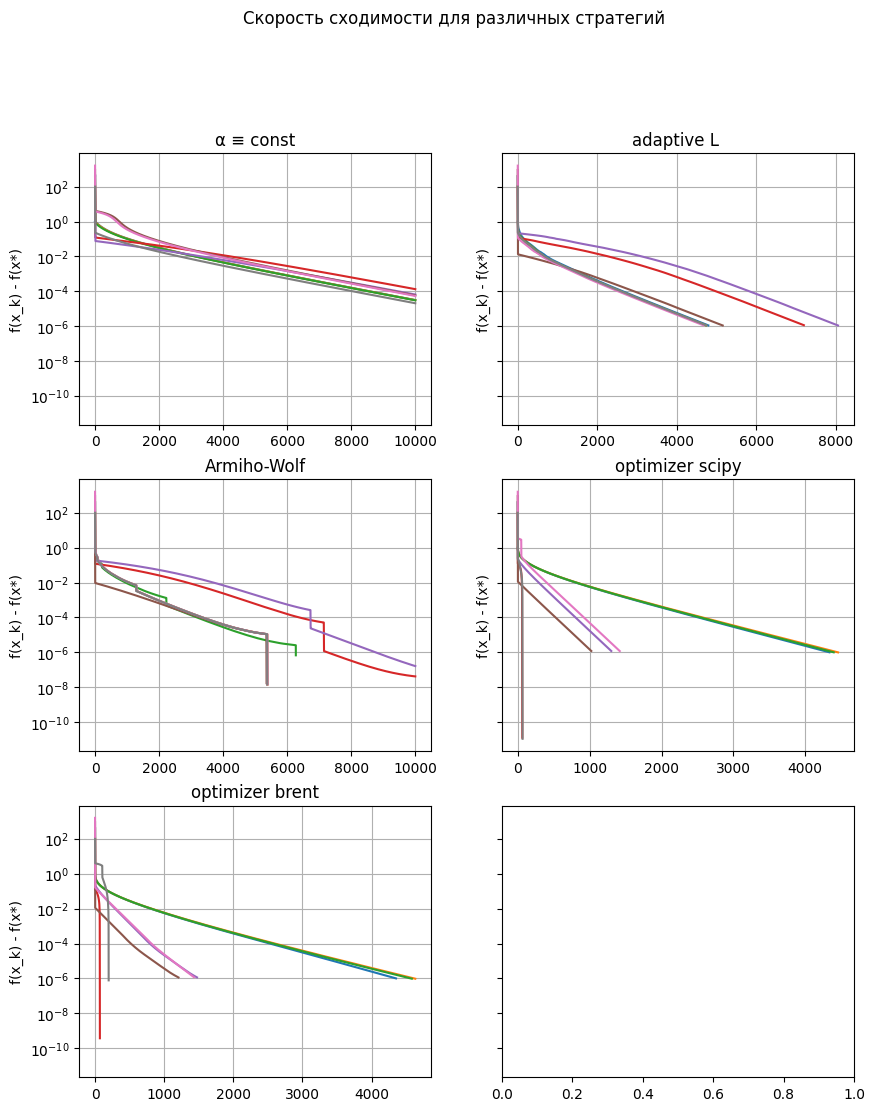

In [39]:
test_convergence_rate(np.array([[0, 0], [0, 1], [0, 2], [1, 2], [2, 2], [2, 1], [2, 0], [1, 0], [1, 1]]))

##### Визуализация хода спуска

In [40]:
def test_visualization(x0):
  fig = plt.figure(figsize=(5*cols, 4*rows))

  # Create meshgrid
  x1_range = np.linspace(-1, 3, 200)
  x2_range = np.linspace(-1, 3, 200)
  X1, X2 = np.meshgrid(x1_range, x2_range)
  Z = np.zeros_like(X1)
  for i in range(X1.shape[0]):
      for j in range(X1.shape[1]):
          x = np.array([X1[i, j], X2[i, j]])
          Z[i, j] = f(x)

  for idx, (method_name, method_func) in enumerate(methods.items()):
      # Get history from method
      points = method_func(x0, h=True)
      z_points = [f(p) for p in points]

      # Create subplot and surface
      ax = fig.add_subplot(rows, cols, idx+1, projection='3d')
      surf = ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.6,
                            edgecolor='none', antialiased=True)

      # Create route
      ax.scatter(points[:, 0], points[:, 1], z_points,
                color='red', s=20, label="Точки", zorder=5, depthshade=True)
      ax.plot(points[:, 0], points[:, 1], z_points,
              color='black', linewidth=2.5, label="Маршрут", zorder=4)

      # Start and end points
      ax.scatter([points[0, 0]], [points[0, 1]], [z_points[0]],
                color='blue', s=40, label="Старт", zorder=6, marker='*')
      if len(points) > 1:
          ax.scatter([points[-1, 0]], [points[-1, 1]], [z_points[-1]],
                    color='green', s=40, label="Финиш", zorder=6, marker='*')

      # Configurate
      ax.set_xlabel('x₁', fontsize=10, labelpad=8)
      ax.set_ylabel('x₂', fontsize=10, labelpad=8)
      ax.set_zlabel('f(x)', fontsize=10, labelpad=8)
      ax.set_title(f'{method_name}', fontsize=12, pad=0)
      ax.view_init(elev=25, azim=135)  # POV
      ax.grid(True, alpha=0.3)


  fig.legend(
    handles=[
      plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='blue',
                markersize=10, label="Начальная точка"),
      plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
                markersize=8, label="Промежуточные точки"),
      plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='green',
                markersize=10, label="Конечная точка"),
      plt.Line2D([0], [0], color='black', linewidth=2.5, label="Маршрут")
    ],
    loc='upper center',
    bbox_to_anchor=(0.5, 1),
    ncol=4,
    frameon=True,
    fancybox=True,
    shadow=True
  )

  plt.suptitle("Визулизация спуска для различных стратегий", y=1.02)
  plt.tight_layout(h_pad=3.0, w_pad=3.0)
  plt.show()

# Заключение

В ходе выполнения лабораторной работы были реализованы и исследованы основные методы одномерной оптимизации нулевого порядка (золотое сечение, параболы, Брента) и метод градиентного спуска с различными стратегиями выбора шага.

На основании проведённых вычислительных экспериментов можно сделать следующие выводы:

- Методы нулевого порядка демонстрируют устойчивую сходимость на гладких унимодальных функциях, при этом метод Брента показывает наилучшую скорость сходимости.
- Градиентный спуск эффективен для минимизации квадратичных функций, при этом выбор оптимального шага существенно ускоряет сходимость.
- На невыпуклых функциях (например, Розенброка) градиентный спуск может сходиться медленно и требовать тщательного подбора параметров.
- Теоретические оценки сходимости (например, для квадратичных функций) хорошо согласуются с результатами численных экспериментов.

Практическое применение изученных методов подтвердило их эффективность для решения задач оптимизации, а также важность корректного выбора параметров и стратегий для обеспечения быстрой и точной сходимости.

# P.S.

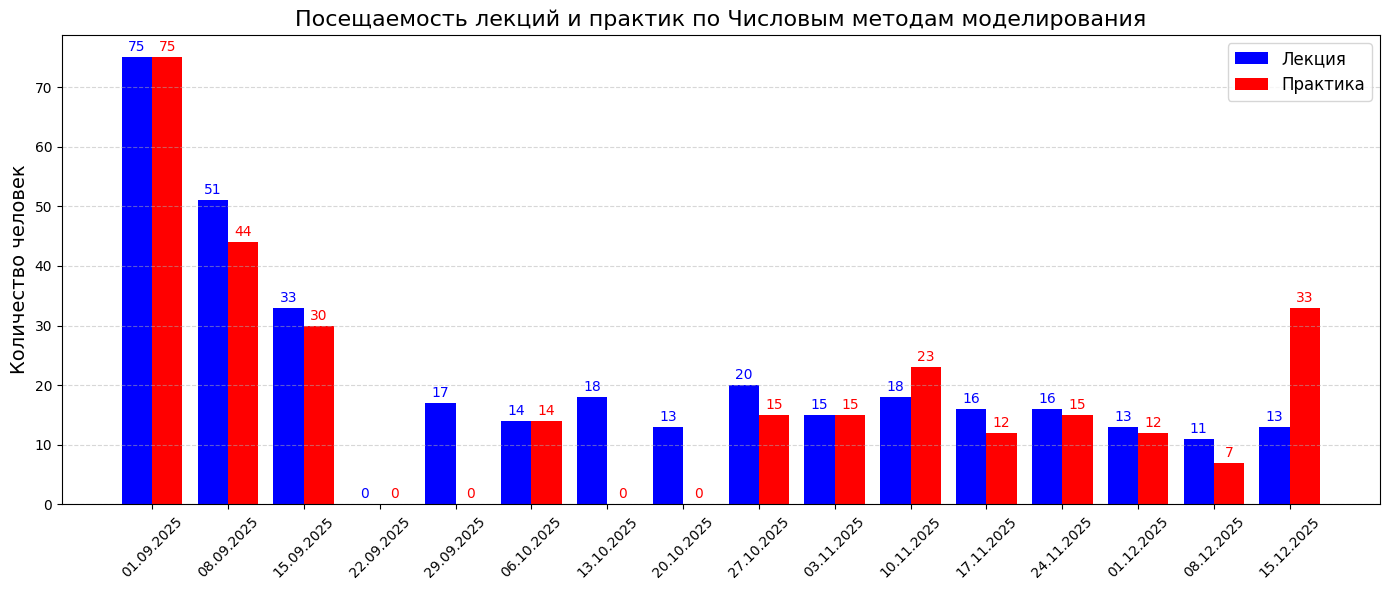

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Даты занятий
dates = [
    "01.09.2025", "08.09.2025", "15.09.2025", "22.09.2025", "29.09.2025",
    "06.10.2025", "13.10.2025", "20.10.2025", "27.10.2025", "03.11.2025",
    "10.11.2025", "17.11.2025", "24.11.2025", "01.12.2025", "08.12.2025",
    "15.12.2025"
]

# Сырые данные лекций и практик
lecture_raw = [
    "75", "56-47", "36-31", "0", "17-18", "16-13", "19-18", "12-14",
    "20", "15", "18", "16", "9;7", "7;8-5", "6;5", "8;5"
]
practice_raw = [
    "75", "48-40", "35-25", "0", "0", "15-13", "0", "0",
    "15", "15", "23", "12", "15", "12", "7", "33"
]

# Функция обработки значений
def process_value(s):
    if "?" in s:
        return 0
    if ";" in s:  # несколько лекций за день
        parts = s.split(";")
        return sum(process_value(p) for p in parts)
    if "-" in s:  # диапазон, усредняем
        parts = list(map(int, s.split("-")))
        return int(sum(parts)/len(parts))
    return int(s)

# Обрабатываем данные
lecture = [process_value(s) for s in lecture_raw]
practice = [process_value(s) for s in practice_raw]

# Создаем DataFrame
df = pd.DataFrame({
    "Date": pd.to_datetime(dates, dayfirst=True),
    "Lecture": lecture,
    "Practice": practice
})

# Настройка позиций для группированных столбцов
x = np.arange(len(df["Date"]))
width = 0.4

# Построение гистограммы
plt.figure(figsize=(14, 6))
plt.bar(x - width/2, df["Lecture"], width, color='blue', label="Лекция")
plt.bar(x + width/2, df["Practice"], width, color='red', label="Практика")

# Подписи с числом студентов над столбцами
for i in range(len(x)):
    plt.text(x[i] - width/2, df["Lecture"][i] + 0.5, str(df["Lecture"][i]), ha='center', va='bottom', fontsize=10, color='blue')
    plt.text(x[i] + width/2, df["Practice"][i] + 0.5, str(df["Practice"][i]), ha='center', va='bottom', fontsize=10, color='red')

# Оформление графика
plt.xticks(x, df["Date"].dt.strftime('%d.%m.%Y'), rotation=45)
plt.ylabel("Количество человек", fontsize=14)
plt.title("Посещаемость лекций и практик по Числовым методам моделирования", fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
